In [1]:
import os, kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# For SQL query
import pantab, tableauhyperapi
from tableauhyperapi import TableName
print(f"Hyper API Version: {tableauhyperapi.__version__}")

path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")
print("Files in dataset:", os.listdir(path))

Hyper API Version: 0.0.24457
Files in dataset: ['Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'P  L March 2021.csv', 'May-2022.csv', 'Sale Report.csv', 'International sale Report.csv', 'Expense IIGF.csv']


In [2]:
# Load Amazon Sales Report
df = pd.read_csv(os.path.join(path, "Amazon Sale Report.csv"), low_memory=False)

print(df.isna().sum(), "\n") # check missing values
print(df.describe(), "\n")
print(df.info(), "\n")
print('shape: ', {df.shape})
display(df.head())

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64 

               index            Qty         Amount  ship-postal-code
count  128975.000000  128975.000000  121180.000000     128942.000000
mean    64487.000000       0.904431     648.561465     463966.236509
std     37232.019822       0.313354     281.211687     191476.764941
min         0.000000       0.000000  

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


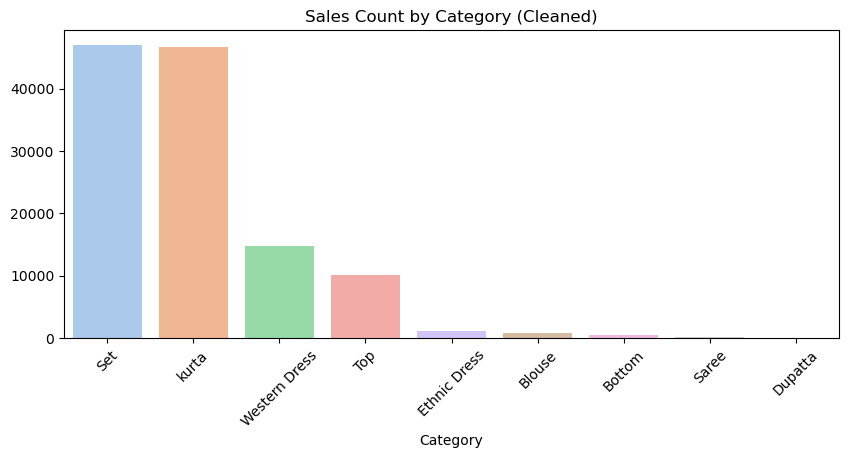

In [4]:
# Drop columns that are irrelevant: 'Unnamed: 22' and 'fulfilled-by' which have huge null counts (49k and 89k)
df = df.drop(columns=['Unnamed: 22', 'fulfilled-by'], errors='ignore')

# Handle missing data in 'Amount' because if there is no Amount, we usually can't use the row for sales analysis
df = df.dropna(subset=['Amount'])

# Handle missing location (ship-city, state, postal-code, country)
location_cols = ['ship-city', 'ship-state', 'ship-country']
df[location_cols] = df[location_cols].fillna('Unknown')
df['ship-postal-code'] = df['ship-postal-code'].fillna(999999.0)

# Handle missing date: Convert and fill missing dates
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')
df['Date'] = df['Date'].ffill()

# Handle other missing data by replacing NaN 
df['Category'] = df['Category'].fillna('Others')
df['Courier Status'] = df['Courier Status'].fillna('Unknown')
df['promotion-ids'] = df['promotion-ids'].fillna('No Promotion')
df['currency'] = df['currency'].fillna('Unknown')

plt.figure(figsize=(10,4))
sns.barplot(x=df['Category'].value_counts().index, 
            y=df['Category'].value_counts().values,
            palette='pastel',
            hue=df['Category'].value_counts().index
           )
plt.title("Sales Count by Category (Cleaned)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Export for Tableau
pantab.frame_to_hyper(df, "ecommerce_cleaned.hyper", table="AmazonSales") # filename, tablename

## Read back .hyper (Tableau ouptut) with pantab

JupyterLab cannot "open" the file like a dashboard, you can use pantab to read it back into a pd.DataFrame or use the hyper kernel on Jupyter Lab to query it using SQL.

In [9]:
# This returns a dictionary where keys are TableName objects and values are DataFrames
schema = pantab.frames_from_hyper("ecommerce_cleaned.hyper")

for table_tuple in schema.keys():
    print(f"Schema: {table_tuple[0]} | Table_name: {table_tuple[1]}")

Schema: public | Table_name: AmazonSales


In [10]:
# Read a specific table from your .hyper file
df_preview = pantab.frame_from_hyper("ecommerce_cleaned.hyper", table="AmazonSales")

# View the first few rows
df_preview.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,__index_level_0__
0,0,405-8078784-5731545,2022-04-30 00:00:00,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,No Promotion,False,0
1,1,171-9198151-1101146,2022-04-30 00:00:00,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,1
2,2,404-0687676-7273146,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,2
3,3,403-9615377-8133951,2022-04-30 00:00:00,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,No Promotion,False,3
4,4,407-1069790-7240320,2022-04-30 00:00:00,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,No Promotion,False,4


In [12]:
# Export to csv
df.to_csv("cleaned_amazon_sales.csv", index=False)